In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
 
# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

work_path = "M:/1confiProj/"
os.chdir(work_path)
from scripts.evaluators import ModelEvaluator
from utils.plot_function import *
from scripts.modelClassGPU import ConfiModel
#from scripts.modelClassGPU_old import ConfiModel as old_model
#from scripts.experiments import Experiment 

device is : cpu


In [3]:
m_label = 'sep_prior'
ev=ModelEvaluator(m_label)

In [10]:
df_sim = ev.get_model_prediction(m_id=1, sub_id=20, nsim = 1000, remove_outliers = False, by='train', print_param=False, interimOutput=False)
df_sim[ 'CISize'].describe()

m:\1confiProj\scripts\experiments.py:183: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)


count    99283.000000
mean         5.765320
std          1.850127
min          0.130523
25%          4.371634
50%          5.745436
75%          7.083835
max         13.203948
Name: CISize, dtype: float64

In [4]:
df_sim = ev.get_allsub_pred_data([1], save_csv=False)

m:\1confiProj\scripts\experiments.py:183: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)
m:\1confiProj\scripts\experiments.py:183: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)
m:\1confiProj\scripts\experiments.py:183: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping column

In [5]:
df_sim[ 'CISize'].describe()

count    794970.000000
mean          6.532216
std           2.854291
min           0.100000
25%           4.512151
50%           6.290601
75%           8.299196
max          19.056341
Name: CISize, dtype: float64

In [9]:
test = ev.test_model_exp(3)


Params for estimation are
sig_Vrh: 2.5987885543411653
sig_Vrl: 5.074497640132904
sig_A: 5.364375494420528
kC1: 0.28894642890881594
mC1: -0.9832804650068283
sig_P_h: 5.369567237794399
sig_P_l: 8.390967287123203
p_com_h: 0.5648295044898987
p_com_l: 0.5159095883369446
rngA: 0.6443261489272117
rngV: 0.6914033576846123
sig_rs: 0.26457471025240054
sig_rconf: 1.999228377290937
sig_rc: 0.40799827868131405
Execution time: 0.482833 seconds


In [4]:
sub_lst = [2, 3, 5, 6 ,11 ,15 ,20]
# read in fit results from old model
fit_res_path = 'M:/1confiProj/adhoc/m0805'
df_res = []
for sub_id in sub_lst:
    filename = 'fitted_sub_' + str(sub_id) + '_m1_bads.pkl'
    df_res.append(pd.read_pickle(os.path.join(fit_res_path, filename)))

df_res = pd.concat(df_res, ignore_index=True)

In [5]:
df_res

,run_id,model_id,sub_id,nll,est_params,init_params,runtime,success
0,20250802_105724,1,2,17861.962292,"[1.1481545731093432, 6.690582275390625, 5.6307...","[0.7650932362060945, 2.766898032820359, 8.8813...",50.221650,True
1,20250802_114812,1,2,18184.109493,"[1.483817153657072, 8.935301959514618, 7.66442...","[1.3296850001002396, 3.5878313710309726, 12.17...",50.783473,True
2,20250802_124550,1,2,17226.196568,"[1.3119128114559648, 8.098221136024222, 6.7759...","[1.945869249891842, 5.016555973141483, 3.22531...",57.639419,True
3,20250802_133809,1,2,17267.023847,"[1.2676673890887922, 7.603790283203125, 5.9409...","[0.5450246407581834, 3.360131955398196, 11.768...",52.315001,True
4,20250802_142820,1,2,17807.685394,"[1.3923543314205833, 8.17236328125, 6.46946907...","[1.3688172909783263, 4.919911897680333, 4.1994...",50.175976,True
...,...,...,...,...,...,...,...,...
58,20250804_234240,1,15,16437.933689,"[1.784981950642711, 9.947272300720215, 10.0051...","[1.0347197443377731, 3.456977532570317, 2.5514...",51.616513,True
59,20250805_003422,1,15,16407.616121,"[2.0506752121002987, 10.74302489310503, 11.412...","[0.7232541565268095, 4.104623816135609, 13.549...",51.700847,True
60,20250805_095136,1,20,16530.483519,"[3.80362772893682, 7.451104164123535, 9.319196...","[1.4441862127232374, 8.68046338784589, 9.76143...",52.204458,True
61,20250805_104618,1,20,16075.194132,"[3.0449271804359497, 5.44751338660717, 6.10454...","[1.6972410280730625, 5.344263573094017, 14.393...",54.699853,True


In [6]:
model = old_model(1)

In [7]:
best_idx = df_res.groupby(['sub_id', 'model_id'])['nll'].idxmin()
df_best_params = df_res.loc[best_idx, ['sub_id', 'model_id', 'est_params', 'nll']].reset_index(drop=True)
df_best_params

,sub_id,model_id,est_params,nll
0,2,1,"[1.2394855586256994, 6.33544921875, 5.13455200...",17177.456775
1,3,1,"[3.0584999534252746, 7.85546875, 7.56213378906...",16440.243086
2,5,1,"[3.0721368339169914, 5.202663421630859, 5.0261...",16699.699733
3,6,1,"[2.187762979388718, 3.0664279460906982, 3.5885...",15475.247178
4,11,1,"[1.9801282031790477, 6.998950625769794, 6.5125...",16411.374232
5,15,1,"[1.7841048142509885, 9.651134490966797, 9.7490...",16370.053637
6,20,1,"[3.0449271804359497, 5.44751338660717, 6.10454...",16075.194132


In [ ]:
def organize_dat(dat, sub_id=999):
        df = pd.DataFrame(dat)
        df.columns =['AudLoc', 'VisLoc', 'VisRel', 'blockType', 'RespLoc', 'CISize', 'Sources', 'ConfLevel']

        df['sub_id'] = sub_id
        df['delta_VA'] = df['VisLoc'] - df['AudLoc']
        df['VisRelLabel'] = df['VisRel'].map({1:'High', 2:'Low'})
        df['Modality'] = df['blockType'].map({0:'V', 1:'A'})

        # get the perceptual bias for bi-modal congruent trials
        df_stat = df.loc[df['AudLoc'] == df['VisLoc']].groupby(['sub_id', 'blockType', 'VisRel', 'AudLoc'])['RespLoc'].agg(['mean', 'std']).reset_index()
        df = df.merge(df_stat, how='left', on=['sub_id', 'blockType', 'VisRel', 'AudLoc'])
        df['bias'] = df['RespLoc'] - df['mean']

        #flip bias
        df['flipBias'] = df['bias'].copy()
        df.loc[df['delta_VA']<0, 'flipBias'] = -df.loc[df['delta_VA']<0, 'flipBias']
        df['abs_delta_VA'] = df.delta_VA.abs()
        return df

In [12]:
df_sim = []
for sub_id in sub_lst:
    dat_sim_t = model.run_simulation(df_best_params.loc[df_best_params.sub_id==sub_id, 'est_params'].values[0], model.getCondRep(nIntSamples = 1000))
    df_sim_t = organize_dat(dat=dat_sim_t, sub_id=sub_id)
    df_sim.append(df_sim_t)
df_sim = pd.concat(df_sim, ignore_index=True)

C:\Users\wenlou\AppData\Local\Temp\ipykernel_16856\236948298.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_16856\236948298.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)
C:\Users\wenlou\AppData\Local\Temp\ipykernel_16856\236948298.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This

In [13]:
df_sim

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,VisRelLabel,Modality,mean,std,bias,flipBias,abs_delta_VA,bias_zscore,CISize_zscore
0,-10.0,-10.0,1.0,1.0,-10.002008,2.994752,1.0,50.0,2,0.0,High,A,-8.330595,2.536318,-1.671413,-1.671413,0.0,-0.658992,-0.877659
1,-10.0,-10.0,1.0,1.0,-9.447865,4.613750,1.0,58.0,2,0.0,High,A,-8.330595,2.536318,-1.117270,-1.117270,0.0,-0.440509,-0.285713
2,-10.0,-10.0,1.0,1.0,-9.315813,4.340595,1.0,51.0,2,0.0,High,A,-8.330595,2.536318,-0.985218,-0.985218,0.0,-0.388444,-0.385586
3,-10.0,-10.0,1.0,1.0,-6.833947,4.960366,1.0,67.0,2,0.0,High,A,-8.330595,2.536318,1.496648,1.496648,0.0,0.590087,-0.158982
4,-10.0,-10.0,1.0,1.0,-7.778917,2.592398,1.0,54.0,2,0.0,High,A,-8.330595,2.536318,0.551678,0.551678,0.0,0.217511,-1.024770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695566,10.0,10.0,2.0,0.0,7.995502,6.404615,1.0,77.0,20,0.0,Low,V,8.143663,3.670465,-0.148161,-0.148161,0.0,-0.040366,0.416858
695567,10.0,10.0,2.0,0.0,6.626077,6.067912,1.0,73.0,20,0.0,Low,V,8.143663,3.670465,-1.517587,-1.517587,0.0,-0.413459,0.120767
695568,10.0,10.0,2.0,0.0,5.167095,5.186018,1.0,74.0,20,0.0,Low,V,8.143663,3.670465,-2.976569,-2.976569,0.0,-0.810951,-0.654754
695569,10.0,10.0,2.0,0.0,6.330297,5.076740,1.0,34.0,20,0.0,Low,V,8.143663,3.670465,-1.813366,-1.813366,0.0,-0.494043,-0.750852


In [14]:
from utils.plot_function import plotDavidFancy

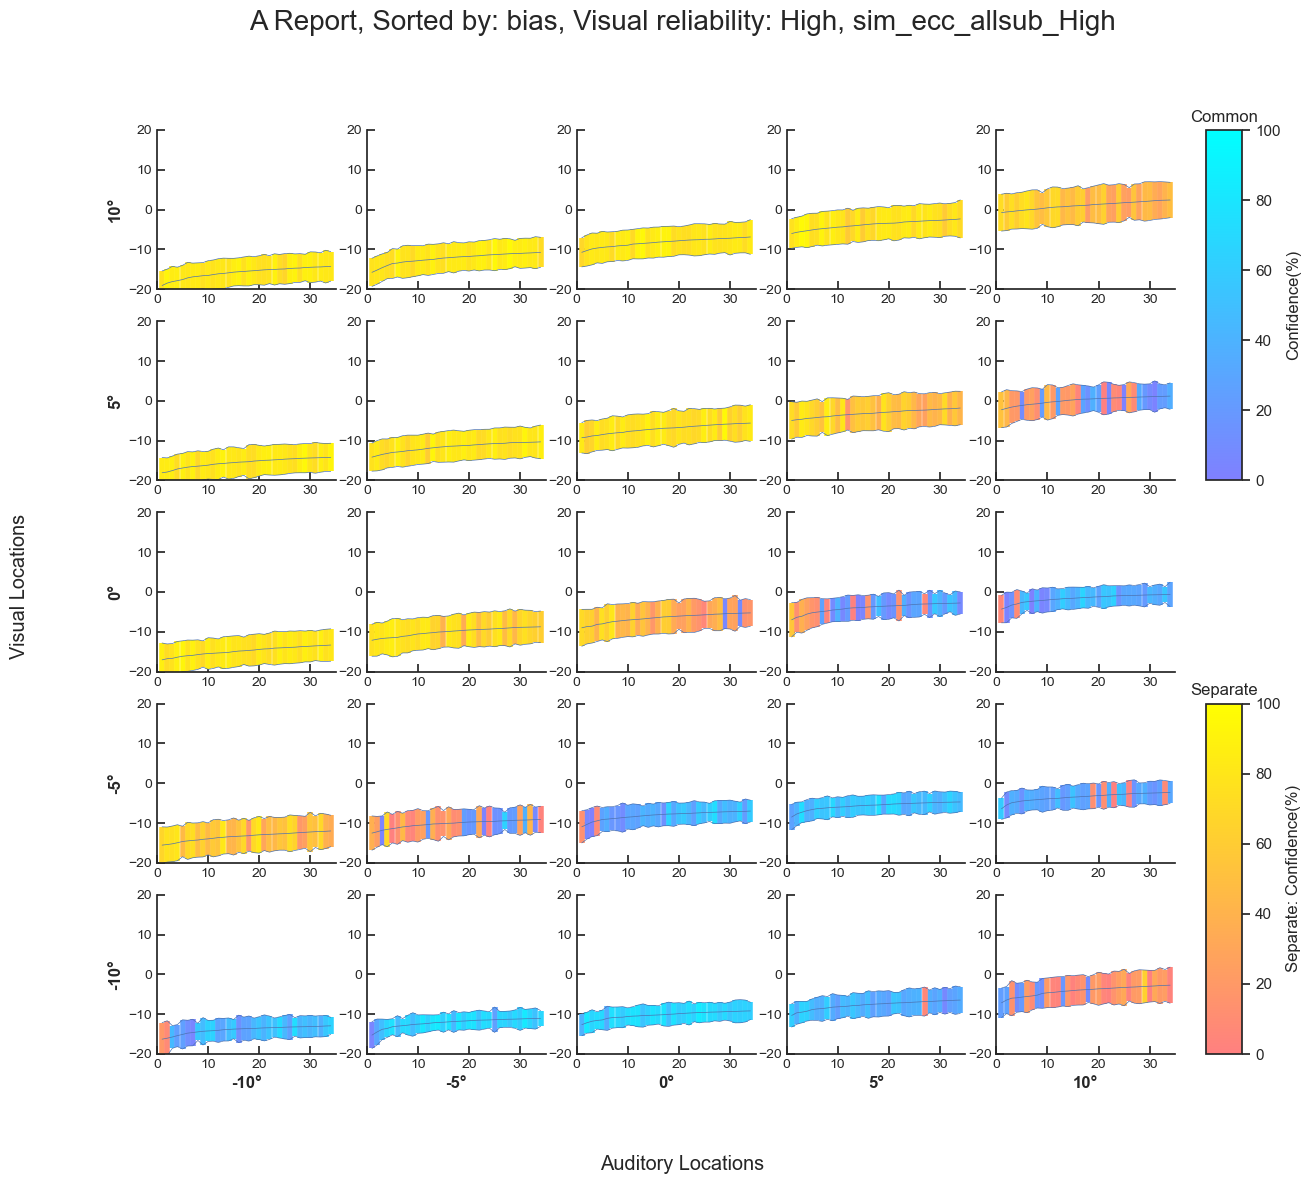

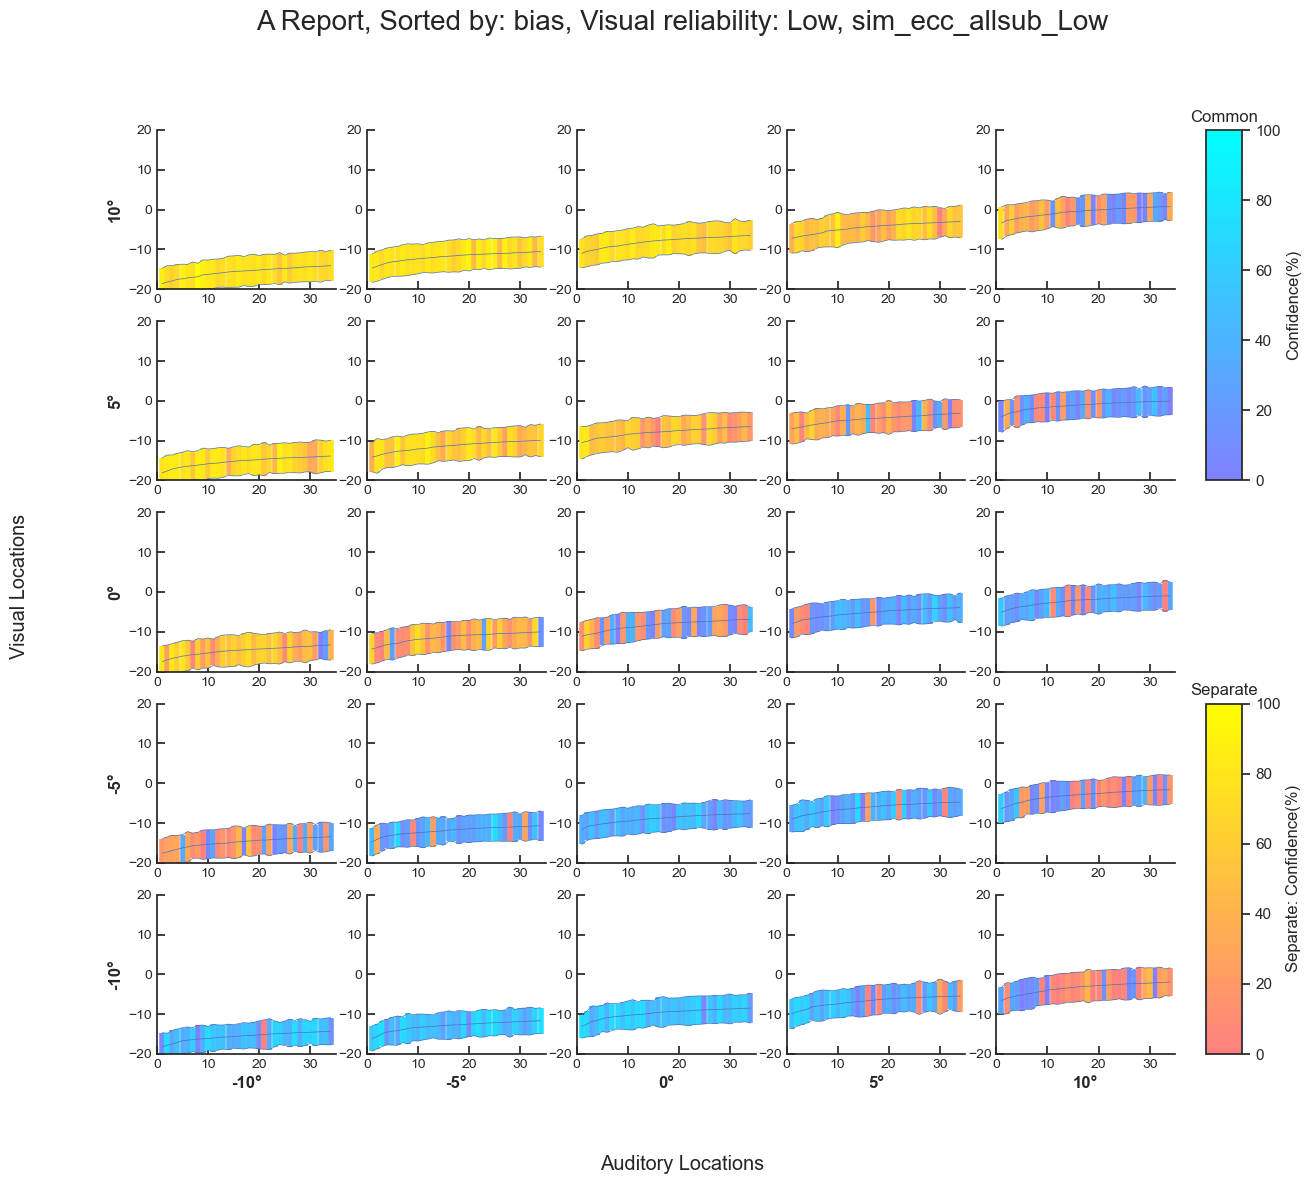

In [15]:
for visrel in ['High', 'Low']:
    plotDavidFancy(df_sim, 'bias', visrel, trial_type='A', \
                    save_fig = 0, plot_label='sim_ecc_allsub_' + visrel)

## Test the entropy model

In [12]:
m_id = 5
ev = ModelEvaluator('base')

In [ ]:
dat_sim, x0 = ev.test_model_exp(5)


Params for estimation are
sig_Vrh: 2.3401580647188447
sig_Vrl: 3.5351638793945312
sig_A: 4.194063663482666
kC1: 1.729391098633299
mC1: 1.4377570152282715
sig_P: 8.131118416786194
p_com: 0.42162537574768066
a: 1
b: 0
sig_rs: 2.3157898242890477e-06
sig_rconf: 1.8125419774487828
sig_rc: 0.31277088317882895
Execution time: 0.603999 seconds


(array([[-10.      , -10.      ,   1.      , ...,  78.76807 ,   1.      ,
         100.      ],
        [-10.      , -10.      ,   1.      , ...,  83.256065,   1.      ,
          46.      ],
        [-10.      , -10.      ,   1.      , ...,  86.67712 ,   2.      ,
         100.      ],
        ...,
        [ 10.      ,  10.      ,   2.      , ...,  83.10582 ,   1.      ,
          88.      ],
        [ 10.      ,  10.      ,   2.      , ...,  84.95124 ,   2.      ,
         100.      ],
        [ 10.      ,  10.      ,   2.      , ...,  82.88466 ,   1.      ,
         100.      ]], shape=(50000, 8), dtype=float32),
 array([ 1.97072999,  4.21530539, 12.10627897, 13.04753363,  4.23757632,
        29.02190089,  0.68619147, 29.34023612,  0.85395923,  0.68701198,
         0.71068313,  0.8033066 ]))

## Test why and if the confidence interval has negative values 

In [2]:
m_id = 1
ev = ModelEvaluator('base')

In [9]:
df_sim, sim_post, sim_post_conf, xA, xV, post_cdf, bin_est, trial_indices, binSize, nbin,ntrial = ev.get_model_prediction(m_id=m_id, sub_id =5, nsim=1000, remove_outliers=False,print_param=True, interimOutput=True)


Params for estimation are
sig_Vrh: 2.19057222039339
sig_Vrl: 6.029435157775879
sig_A: 6.245707988739014
kC1: 0.19529930807210158
mC1: -0.5633509159088135
sig_P: 7.2560834884643555
p_com: 0.5316425800323487
rng: 0.5475005149841308
sig_rs: 0.11303801031947909
sig_rconf: 1.6313710998215016
sig_rc: 0.2758020018206244


In [10]:
df_sim.CISize.describe()

count    100000.000000
mean          6.818293
std           1.382704
min           5.050505
25%           5.050505
50%           7.070707
75%           8.080808
max          11.111111
Name: CISize, dtype: float64

In [15]:
rng=0.3
resp = torch.zeros((ntrial, 4), dtype=torch.float32)
# Complex interval computation - keeping original logic but with PyTorch
center_cdf = post_cdf[bin_est, trial_indices]

# The cap trials will have bigger intervals
cap_trial_l = (center_cdf < rng/2) | (bin_est == 0)
#cap_trial_r = (center_cdf > 1-rng/2) | (bin_est == nbin - 1)

# Init array to save the best bin size (to cover rng%)
best_bin_n = torch.ones(ntrial,  dtype=torch.long)
# Main loop for non-capped trials
while True:
    half_width = ((best_bin_n - 1) // 2)
    start_bin = torch.clamp(bin_est - half_width - 1, 0, nbin - 1)
    end_bin = torch.clamp(bin_est + half_width, 0, nbin - 1)
    prob_rng = post_cdf[end_bin, trial_indices] - post_cdf[start_bin, trial_indices]

    need_more_bins = (prob_rng < rng) & (~cap_trial_l)
    if not torch.any(need_more_bins):
        break
    best_bin_n[need_more_bins] += 2
    
resp[~cap_trial_l, 1] = binSize * (end_bin[~cap_trial_l] - start_bin[~cap_trial_l] + 1).float() 
#resp[~cap_trial_l, 1] = params.a * binSize * (end_bin[~cap_trial_l] - start_bin[~cap_trial_l] + 1).float() + params.b
# Compute separately for cap_trial_l 


In [14]:
cap_trial_l.sum()

tensor(0)

In [16]:
pd.Series(resp[~cap_trial_l, 1].numpy()).describe()

count    100000.000000
mean          3.596556
std           1.159366
min           2.020202
25%           2.020202
50%           4.040404
75%           4.040404
max           8.080808
dtype: float64

In [11]:
best_bin_n = torch.ones(ntrial,  dtype=torch.long)
while True:
    half_width = ((best_bin_n - 1) // 2)
    end_bin = torch.clamp(bin_est + half_width, 0, nbin-1)
    prob_rng = post_cdf[end_bin, trial_indices]
    
    need_more_bins = (prob_rng < rng) & cap_trial_l
    if not torch.any(need_more_bins):
        break  
    best_bin_n[need_more_bins] += 2
    
resp[cap_trial_l, 1] =  binSize * (end_bin[cap_trial_l] + 1).float() 

In [12]:
pd.Series(resp[cap_trial_l, 1].numpy()).describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
dtype: float64

In [5]:
df_sim

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,VisRelLabel,bias,flipBias,abs_delta_VA
0,-10.0,-10.0,1.0,1.0,-10.456830,2.063213,1.0,68.0,2,0.0,High,-0.456830,-0.456830,0.0
1,-10.0,-10.0,1.0,1.0,-10.061847,2.911993,1.0,91.0,2,0.0,High,-0.061847,-0.061847,0.0
2,-10.0,-10.0,1.0,1.0,-6.247807,9.751369,1.0,26.0,2,0.0,High,3.752193,3.752193,0.0
3,-10.0,-10.0,1.0,1.0,-7.654376,5.052787,1.0,87.0,2,0.0,High,2.345624,2.345624,0.0
4,-10.0,-10.0,1.0,1.0,-8.597075,8.694487,1.0,42.0,2,0.0,High,1.402925,1.402925,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10.0,10.0,2.0,0.0,7.071138,11.842228,1.0,58.0,2,0.0,Low,-2.928862,-2.928862,0.0
99996,10.0,10.0,2.0,0.0,8.663217,10.748188,1.0,77.0,2,0.0,Low,-1.336783,-1.336783,0.0
99997,10.0,10.0,2.0,0.0,15.060570,7.523440,1.0,66.0,2,0.0,Low,5.060570,5.060570,0.0
99998,10.0,10.0,2.0,0.0,7.418635,7.824474,1.0,65.0,2,0.0,Low,-2.581365,-2.581365,0.0


In [5]:
df_sim.loc[df_sim.CISize<0].describe()

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,bias,flipBias,abs_delta_VA
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
for mid in [1, 2, 3, 4]:
    for sub_id in sub_lst:
        res_file = os.path.join(fit_res_path, f"model_{mid}", f"fitted_sub_{sub_id}_m{mid}_bads.pkl")  
        df = pd.read_pickle(res_file)
        df['model_id'] = mid
        df.to_pickle(os.path.join(fit_res_path,  f"model_{mid}", f"fitted_sub_{sub_id}_m{mid}_bads.pkl"))
        #df_new = df[10:].copy().reset_index(drop=True)
        #df_new.to_pickle(os.path.join(fit_res_path, f"model_{model_id}", f"fitted_sub_{sub_id}_m{model_id}_bads.pkl") )

In [6]:
mid=1;sub_id=2
res_file = os.path.join('M:\\1confiProj\\fit_res\\archieve\\output', f"model_{mid}", f"fitted_sub_{sub_id}_m{mid}_bads.pkl")  
df = pd.read_pickle(res_file)

In [7]:
df.head()

,run_id,model_id,sub_id,nll,est_params,init_params,runtime,success
0,20250802_105724,1,2,17861.962292,"[1.1481545731093432, 6.690582275390625, 5.6307...","[0.7650932362060945, 2.766898032820359, 8.8813...",50.221650,True
1,20250802_114812,1,2,18184.109493,"[1.483817153657072, 8.935301959514618, 7.66442...","[1.3296850001002396, 3.5878313710309726, 12.17...",50.783473,True
2,20250802_124550,1,2,17226.196568,"[1.3119128114559648, 8.098221136024222, 6.7759...","[1.945869249891842, 5.016555973141483, 3.22531...",57.639419,True
3,20250802_133809,1,2,17267.023847,"[1.2676673890887922, 7.603790283203125, 5.9409...","[0.5450246407581834, 3.360131955398196, 11.768...",52.315001,True
4,20250802_142820,1,2,17807.685394,"[1.3923543314205833, 8.17236328125, 6.46946907...","[1.3688172909783263, 4.919911897680333, 4.1994...",50.175976,True


In [ ]:
df = pd.read_pickle('M:\\1confiProj\\Analysis\\all_model_best_params.pkl')
df
[1.23948556e+00 6.33544922e+00 5.13455200e+00 7.82382965e+00
 4.68270874e-01 6.38450413e-04 9.99993645e-01 2.19492196e-01
 5.77907181e-01 2.46387277e+00 1.17092133e+00 8.20318898e+00
 5.14930725e+00]

#df_new = df[10:].copy().reset_index(drop=True)
#df_new.to_pickle(os.path.join(fit_res_path, f"model_{model_id}", f"fitted_sub_{sub_id}_m{model_id}_bads.pkl") )

,sub_id,model_id,est_params,aic
0,2,1,"[1.2394855586256994, 6.33544921875, 5.13455200...",17203.456775
1,2,2,"[2.2387935500677676, 7.214092254638672, 5.9428...",17890.222258
2,2,3,"[1.2888414853325905, 8.545191705226898, 7.0306...",16929.307334
3,2,4,"[2.0062757800486892, 6.3537139892578125, 5.002...",17141.538518
4,2,5,"[1.426677757113247, 19.92847339808941, 4.84314...",21679.461265
...,...,...,...,...
59,25,4,"[2.7212848774034017, 6.6210479736328125, 5.901...",17222.281336
60,25,5,"[1.5895209085152233, 19.99976964649977, 5.3889...",20783.274877
61,25,6,"[1.9290447439528122, 18.288956105709076, 5.607...",20857.001318
62,25,7,"[0.7482542760244699, 19.394351043196366, 4.923...",20770.604999


In [3]:
len(df)

64

In [3]:
df_sim = pd.DataFrame()
for model_id in [1, 2, 3, 4]:
    for sub_id in sub_lst:
        model = ConfiModel(model_id)
        df_sim_sub = get_model_prediction(model, sub_id)
        df_sim_sub['model_id'] = model_id
        df_sim = pd.concat([df_sim, df_sim_sub], ignore_index = True)

M:\1confiProj\utils\help_function.py:110: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_best_params = df[['sub_id', 'model_id', 'est_params','nll']].groupby(['sub_id', 'model_id']).apply(
M:\1confiProj\utils\help_function.py:110: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_best_params = df[['sub_id', 'model_id', 'est_params','nll']].groupby(['sub_id', 'model_id']).apply(
M:\1confiProj\utils\help_function.py:1

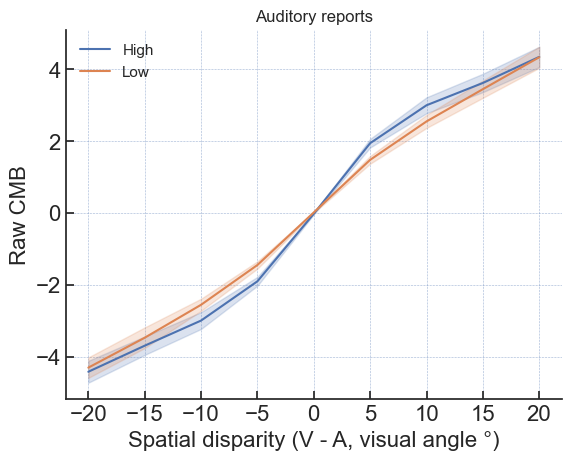

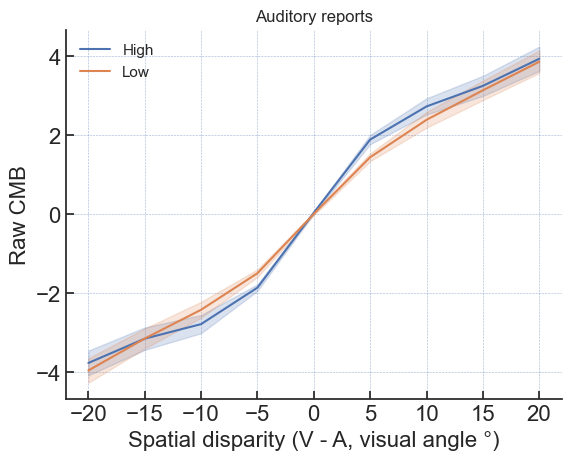

In [ ]:

plot_VE(df_sim.loc[df_sim.model_id==2],  1)
plot_VE(df_sim.loc[df_sim.model_id==4],  1)

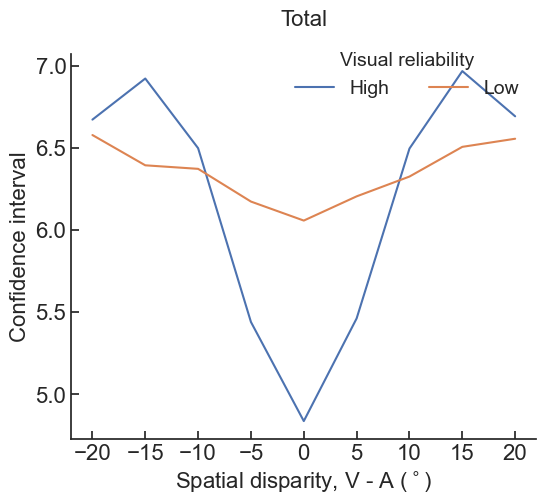

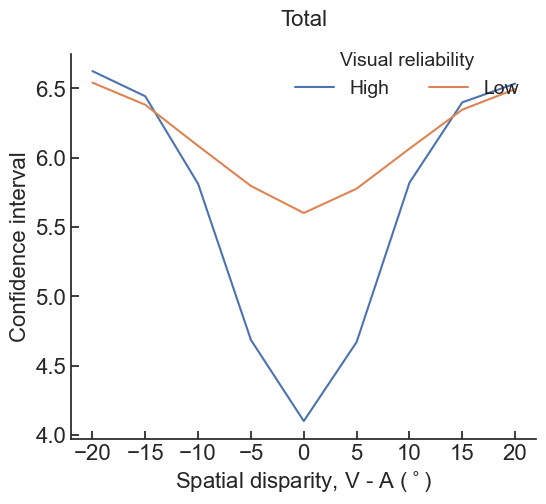

In [13]:
sid = 11
plot_group_pattern(df_sim.loc[(df_sim.model_id==1)&(df_sim.sub_id == sid)], 'CISize', 'Total')
plot_group_pattern(df_sim.loc[(df_sim.model_id==2)&(df_sim.sub_id == sid)], 'CISize', 'Total')

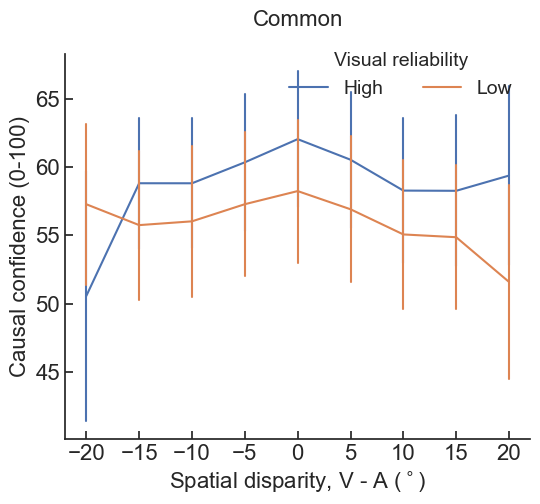

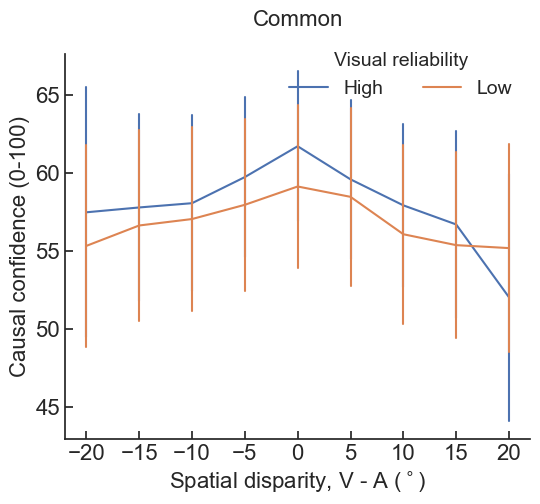

In [ ]:
plot_group_pattern(df_sim.loc[df_sim.model_id==1], 'ConfLevel', 'Common')
plot_group_pattern(df_sim.loc[df_sim.model_id==3], 'ConfLevel', 'Common')

In [12]:
# for debugging
# import cProfile
# import pstats
sub_id = 25

#load behavioral quantitle data
bin_data = pickle.load(open(os.path.join(fit_data_path, 'beh_bin_sub_' + str(sub_id) + '.pkl'), 'rb'))


In [9]:
#how many data are outliers
sub_data = np.loadtxt(os.path.join(fit_data_path, 'beh_data_sub_' + str(sub_id) + '.csv'), delimiter=',')
df_sub = organize_sim_data(sub_data, sub_id=sub_id)
# remove outliers
df_sub['CISize_zscore'] = (df_sub['CISize'] - df_sub['CISize'].mean()) / df_sub['CISize'].std()
(df_sub.CISize_zscore.abs() >=3).sum()/ len(df_sub)

np.float64(0.0028501628664495114)